# Карта ДТП

https://dtp-stat.ru/pages/about/?ysclid=mqnzsthp1d506825474$0

Некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах.


## Оглавление

1. Цель и задачи исследования
   
   1.1. Описание данных

   1.2 Загрузка основных библиотек


2. Сбор, загрузка и обработка данных по Кировской области

   2.1 Датафрейм ko - информация о ДТП в Кировской области

   2.2 Датафрейм participants_ko - информация об участниках ДТП в Кировской области

   2.3 Датафрейм vehicles_ko - информация о т/с в Кировской области

3. Сбор, загрузка и обработка данных по Московской области

   3.1 Датафрейм mo - информация о ДТП в Московской области

   3.2 Датафрейм participants_mo - информация об участниках ДТП в Московской области

   3.3 Датафрейм vehicles_mo - информация о т/с в Московской области

4. Динамика ДТП по временным промежуткам в Кировской области

   4.1 График по месяцам и годам за весь период

   4.2 График по дням недели за весь период

   4.3 График по месяцам за весь период

   4.4 График по годам за весь период

5. Сравнение количества ДТП между группами водителей с разным стажем в Кировской области

6. Выводы

## 1. Цель и задачи исследования

В рамках проекта проводится анализ данных о дорожно-транспортных происшествиях

**Интервал исследования:**
С января 2015 года до августа 2024 года включительно (9 лет и 8 месяцев)

**Основная цель исследования** — оценить качество собранных данных, выявив возможные дубликаты и пропущенные значения, а также изучить ключевые закономерности в статистике ДТП.

**Задачи исследования:**

1) изучить динамику ДТП;

2) сравнить количество ДТП для групп водителей с разным стажем.

### 1.1 Описание данных

Данные `Kirovskaya_oblast.csv`, `Moscowskaya_oblast.csv` содержат информацию ДТП:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

*  `properties.tags` — тег происшествия;

*  `properties.light` — освещённость;

*  `properties.point.lat` — широта;

*  `properties.point.long` — долгота;

*  `properties.nearby` — ближайшие объекты;

*  `properties.region` — регион;

*  `properties.scheme` — схема ДТП;

*  `properties.address` — ближайший адрес;

*  `properties.weather` — погода;

*  `properties.category` — категория ДТП;

*  `properties.datetime` — дата и время ДТП;

*  `properties.injured_count` — число пострадавших;

*  `properties.parent_region` — область;

*  `properties.road_conditions` — состояние покрытия;

*  `properties.participants_count` — число участников;

*  `properties.participant_categories` — категории участников.

`Moscowskaya_oblast_participiants.csv`, `Kirovskaya_oblast_participiants.csv` — сведения об участниках ДТП:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после  ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


`Kirovskaya_oblast_vehicles.csv`, `Moscowskaya_oblast_vehicles.csv` — сведения о транспортных средствах:

* `year` — год выпуска;

* `brand` — марка транспортного средства;

* `color` — цвет;

* `model` — модель;

* `category` — категория;

* `id` — идентификатор ДТП.

### 1.2 Загрузка основных библиотек

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 2. Сбор, загрузка и обработка данных по Кировской области

In [2]:
# Информация о ДТП в Кировской области
ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv')

# Информация об участниках ДТП в Кировской области
participants_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv')

# Информация о т/с в Кировской области
vehicles_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv')

### 2.1 Датафрейм ko - информация о ДТП в Кировской области

In [3]:
# Для более удобной работы сокращу названия столбцов
# Создам функцию, чтобы потом применить ее и для МО

def new_name_columns(df):
  new_columns = df.rename(columns={'properties.tags': 'tags', 'properties.light': 'light',
                          'properties.point.lat': 'point.lat', 'properties.point.long': 'point.long',
                          'properties.nearby': 'nearby', 'properties.region': 'region', 'properties.scheme': 'scheme',
                          'properties.address': 'address', 'properties.weather': 'weather', 'properties.category': 'category',
                          'properties.datetime': 'datetime', 'properties.injured_count': 'injured_count', 'properties.parent_region': 'parent_region',
                          'properties.road_conditions': 'road_conditions', 'properties.participants_count': 'participants_count',
                          'properties.participant_categories': 'participant_categories'})
  return new_columns

In [4]:
ko = new_name_columns(ko)

In [5]:
ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    14517 non-null  object 
 1   id                      14517 non-null  int64  
 2   tags                    14517 non-null  object 
 3   light                   14517 non-null  object 
 4   point.lat               14485 non-null  float64
 5   point.long              14485 non-null  float64
 6   nearby                  14517 non-null  object 
 7   region                  14517 non-null  object 
 8   scheme                  13380 non-null  float64
 9   address                 13843 non-null  object 
 10  weather                 14517 non-null  object 
 11  category                14517 non-null  object 
 12  datetime                14517 non-null  object 
 13  injured_count           14517 non-null  int64  
 14  parent_region           14517 non-null

In [6]:
# Проверю пропуски в данных
ko.isna().sum().sort_values(ascending = False)

,0
scheme,1137
address,674
point.long,32
point.lat,32
id,0
geometry.coordinates,0
tags,0
light,0
region,0
nearby,0


In [7]:
# В столбце point.lat - 32 пропуска, что составляет около 0,22% от общего числа строк
# Удалю строки с пропусками в координатах

ko = ko.dropna(subset=['point.lat', 'point.long'])

In [8]:
# Указываю "схема отсутствует" и "адрес отсутствует", чтобы закрыть пропуски
ko['scheme'] = ko['scheme'].fillna('схема отсутствует')
ko['address'] = ko['address'].fillna('адрес отсутствует')

In [9]:
# Проверяю на явные дубликаты
ko.duplicated().sum()

np.int64(0)

In [10]:
# Финально проверю пропуски в данных
ko.isna().sum().sort_values(ascending = False)

,0
geometry.coordinates,0
id,0
tags,0
light,0
point.lat,0
point.long,0
nearby,0
region,0
scheme,0
address,0


### 2.2 Датафрейм participants_ko - информация об участниках ДТП в Кировской области

In [11]:
participants_ko.head(3)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208


In [12]:
participants_ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31235 entries, 0 to 31234
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         31235 non-null  object 
 1   gender                       30387 non-null  object 
 2   violations                   31235 non-null  object 
 3   health_status                31135 non-null  object 
 4   years_of_driving_experience  16909 non-null  float64
 5   id                           31235 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


In [13]:
# Проверю пропуски в данных
participants_ko.isna().sum().sort_values(ascending=False)

,0
years_of_driving_experience,14326
gender,848
health_status,100
role,0
violations,0
id,0


In [14]:
# Пропуски в поле пола составляют 2,71%, в поле состояния здоровья — 0,32%.
# Удалю строки с пропуском хотя бы в одном из этих полей.

participants_ko = participants_ko.dropna(subset=['gender', 'health_status'])

In [15]:
# Проверю пропуски в данных
participants_ko.isna().sum().sort_values(ascending=False)

,0
years_of_driving_experience,13659
role,0
gender,0
violations,0
health_status,0
id,0


In [16]:
participants_ko.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


Есть гипотеза, что NaN в столбце years_of_driving_experience очень много, так как стаж указан только у водителей

In [17]:
pd.crosstab(
    participants_ko['role'],
    participants_ko['years_of_driving_experience'].isna(),
    margins=True).rename(columns={False: 'Стаж указан', True: 'Стаж не указан'})

years_of_driving_experience,Стаж указан,Стаж не указан,All
role,,,
Велосипедист,0,333,333
Водитель,16726,2290,19016
Пассажир,0,6697,6697
Пешеход,0,4279,4279
"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира",0,60,60
All,16726,13659,30385


In [18]:
# Стаж заполнен только у водителей.
# Большая часть пропусков объясняется другими ролями участников, однако у 2 290 водителей стаж также неизвестен.

# Чтобы не смешивать числа и текст в одном столбце, и не усложнять дальнейшие расчёты и группировку, оставляю NaN:
# для пассажира стаж неприменим, для водителя — неизвестен.

In [19]:
participants_ko.isna().sum()

,0
role,0
gender,0
violations,0
health_status,0
years_of_driving_experience,13659
id,0


In [20]:
# Проверяю на явные дубликаты
participants_ko.duplicated().sum()

np.int64(9435)

### 2.3 Датафрейм vehicles_ko - информация о т/с в Кировской области

In [21]:
vehicles_ko.head(3)

,year,brand,color,model,category,id
0,2011.0,ВАЗ,Серый,Kalina,"А-класс (особо малый) до 3,5 м",1983180
1,2005.0,CHEVROLET,Зеленый,Niva,"С-класс (малый средний, компактный) до 4,3 м",2889433
2,2017.0,RENAULT,Синий,Logan,"С-класс (малый средний, компактный) до 4,3 м",2591208


In [22]:
vehicles_ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20093 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19299 non-null  float64
 1   brand     19318 non-null  object 
 2   color     19643 non-null  object 
 3   model     19318 non-null  object 
 4   category  20093 non-null  object 
 5   id        20093 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 942.0+ KB


In [23]:
vehicles_ko.isna().sum().sort_values(ascending=False)

,0
year,794
brand,775
model,775
color,450
category,0
id,0


* В столбце year — 794 пропуска (3,95%).

* В столбце brand — 775 пропусков (3,86%).

* В столбце model — 775 пропусков (3,86%).

* В столбце color — 450 пропусков (2,24%).

Доля пропусков во всех столбцах не превышает 5%, поэтому данные пропуски удаляю.

In [24]:
vehicles_ko = vehicles_ko.dropna(subset=['year', 'brand', 'model', 'color'])

In [25]:
vehicles_ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19147 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19147 non-null  float64
 1   brand     19147 non-null  object 
 2   color     19147 non-null  object 
 3   model     19147 non-null  object 
 4   category  19147 non-null  object 
 5   id        19147 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


In [26]:
# После удаления строк с пропусками в годе выпуска, марке, модели или цвете исключено 946 записей — 4,71% исходной таблицы.
# Это меньше принятого для этой таблицы порога в 5%.

In [27]:
# Проверяю на явные дубликаты
vehicles_ko.duplicated().sum()

np.int64(7)

In [28]:
# Нахожу 7 дубликатов и удаляю их

vehicles_ko = vehicles_ko.drop_duplicates()

## 3. Сбор, загрузка и обработка данных по Московской области

In [29]:
# Информация о ДТП в Московской области
mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv')

# Информация об участниках ДТП в Московской области
participants_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv')


# Информация о т/с в Московской области
vehicles_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv')

### 3.1 Датафрейм mo - информация о ДТП в Московской области

In [30]:
mo = new_name_columns(mo)

In [31]:
mo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45618 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    45618 non-null  object 
 1   id                      45618 non-null  int64  
 2   tags                    45618 non-null  object 
 3   light                   45618 non-null  object 
 4   point.lat               45615 non-null  float64
 5   point.long              45615 non-null  float64
 6   nearby                  45618 non-null  object 
 7   region                  45618 non-null  object 
 8   scheme                  44235 non-null  float64
 9   address                 43862 non-null  object 
 10  weather                 45618 non-null  object 
 11  category                45618 non-null  object 
 12  datetime                45618 non-null  object 
 13  injured_count           45618 non-null  int64  
 14  parent_region           45618 non-null

In [32]:
# Проверю пропуски в данных
mo.isna().sum().sort_values(ascending = False)

,0
address,1756
scheme,1383
point.long,3
point.lat,3
id,0
geometry.coordinates,0
tags,0
light,0
region,0
nearby,0


In [33]:
# В столбцах point.lat и point.long - 3 пропуска, что составляет менее 1% от общего числа строк
# Удалю строки с пропусками в координатах

mo = mo.dropna(subset=['point.lat', 'point.long'])

In [34]:
# Указываю "схема отсутствует" и "адрес отсутствует", чтобы закрыть пропуски
mo['scheme'] = mo['scheme'].fillna('схема отсутствует')
mo['address'] = mo['address'].fillna('адрес отсутствует')

In [35]:
# Проверяю на явные дубликаты
mo.duplicated().sum()

np.int64(0)

In [36]:
# Финально проверю пропуски в данных
mo.isna().sum().sort_values(ascending = False)

,0
geometry.coordinates,0
id,0
tags,0
light,0
point.lat,0
point.long,0
nearby,0
region,0
scheme,0
address,0


### 3.2 Датафрейм participants_mo - информация об участниках ДТП в Московской области

In [37]:
participants_mo.head(3)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,[],Не пострадал,13.0,2163589
1,Водитель,Мужской,[],Не пострадал,13.0,2163589
2,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398


In [38]:
participants_mo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95177 entries, 0 to 95176
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         95177 non-null  object 
 1   gender                       93307 non-null  object 
 2   violations                   95177 non-null  object 
 3   health_status                95070 non-null  object 
 4   years_of_driving_experience  59679 non-null  float64
 5   id                           95177 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 4.4+ MB


In [39]:
# Проверяю пропуски в данных
participants_mo.isna().sum().sort_values(ascending=False)

,0
years_of_driving_experience,35498
gender,1870
health_status,107
role,0
violations,0
id,0


In [40]:
# Пропуски в поле пола составляют 1,96%, в поле состояния здоровья — 0,11%.
# Удалю строки с пропуском хотя бы в одном из этих полей.

participants_mo = participants_mo.dropna(subset=['gender', 'health_status'])

In [41]:
# Проверяю пропуски в данных
participants_mo.isna().sum().sort_values(ascending=False)

,0
years_of_driving_experience,34322
role,0
gender,0
violations,0
health_status,0
id,0


In [42]:
participants_mo.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,[],Не пострадал,13.0,2163589
1,Водитель,Мужской,[],Не пострадал,13.0,2163589
2,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
3,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
4,Водитель,Женский,[],Не пострадал,11.0,2163319


Есть гипотеза, что NaN в столбце years_of_driving_experience очень много, так как стаж указан только у водителей

In [43]:
pd.crosstab(
    participants_mo['role'],
    participants_mo['years_of_driving_experience'].isna(),
    margins=True).rename(columns={False: 'Стаж указан', True: 'Стаж не указан'})

years_of_driving_experience,Стаж указан,Стаж не указан,All
role,,,
Велосипедист,0,916,916
Водитель,58983,4175,63158
Пассажир,0,16441,16441
Пешеход,0,12479,12479
"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира",0,311,311
All,58983,34322,93305


In [44]:
# Стаж заполнен только у водителей.
# Большая часть пропусков объясняется другими ролями участников, однако у 4 175 водителей стаж также неизвестен.

# Чтобы не смешивать числа и текст в одном столбце, и не усложнять дальнейшие расчёты и группировку, оставляю NaN:
# для пассажира стаж неприменим, для водителя — неизвестен.

In [45]:
# Проверяю на явные дубликаты
participants_mo.duplicated().sum()

np.int64(34743)

In [46]:
# Найдено 34 743 полностью совпадающих строки — 37,24% оставшихся записей
# Удаление затронуло бы больше трети записей.
# Поскольку совпадения могут описывать разных участников одного ДТП, сохраняю эти строки.

### 3.3 Датафрейм vehicles_mo - информация о т/с в Московской области

In [47]:
vehicles_mo.head(3)

,year,brand,color,model,category,id
0,2012.0,ГАЗ,Белый,Прочие модели ГАЗ,Фургоны,2163589
1,2008.0,OPEL,Черный,Astra,"С-класс (малый средний, компактный) до 4,3 м",2155398
2,2017.0,MAZDA,Черный,CX-5,"В-класс (малый) до 3,9 м",2163319


In [48]:
vehicles_mo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65606 entries, 0 to 65605
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      63860 non-null  float64
 1   brand     64185 non-null  object 
 2   color     64765 non-null  object 
 3   model     64185 non-null  object 
 4   category  65606 non-null  object 
 5   id        65606 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 3.0+ MB


In [49]:
vehicles_mo.isna().sum().sort_values(ascending=False)

,0
year,1746
brand,1421
model,1421
color,841
category,0
id,0


* В столбце year — 1746 пропусков (2,66%).

* В столбце brand — 1421 пропуск (2,17%).

* В столбце model — 1421 пропуск (2,17%).

* В столбце color — 841 пропуск (1,28%).

Доля пропусков во всех столбцах не превышает 5%, поэтому данные пропуски удаляю.

In [50]:
vehicles_mo = vehicles_mo.dropna(subset=['year', 'brand', 'model', 'color'])

In [51]:
vehicles_mo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63728 entries, 0 to 65605
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      63728 non-null  float64
 1   brand     63728 non-null  object 
 2   color     63728 non-null  object 
 3   model     63728 non-null  object 
 4   category  63728 non-null  object 
 5   id        63728 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 3.4+ MB


In [52]:
# После удаления строк с пропусками в годе выпуска, марке, модели или цвете исключено 1 878 записей — 2,86% исходной таблицы.
# Это меньше принятого для этой таблицы порога в 5%.

In [53]:
# Проверяю на явные дубликаты
vehicles_mo.duplicated().sum()

np.int64(684)

In [54]:
# Нахожу 684 дубликата и удаляю их


vehicles_mo = vehicles_mo.drop_duplicates()

## 4. Динамика ДТП по временным промежуткам в Кировской области

In [55]:
ko['datetime'] = pd.to_datetime(ko['datetime'])

In [56]:
ko['month'] = ko['datetime'].dt.to_period('M')

ko['week'] = ko['datetime'].dt.day_name()

### 4.1 График за весь период исследования с обозначением пиков и среднего количества ДТП

In [57]:
df = ko.groupby('month')['id'].size()
df_week = ko.groupby('week')['id'].size()

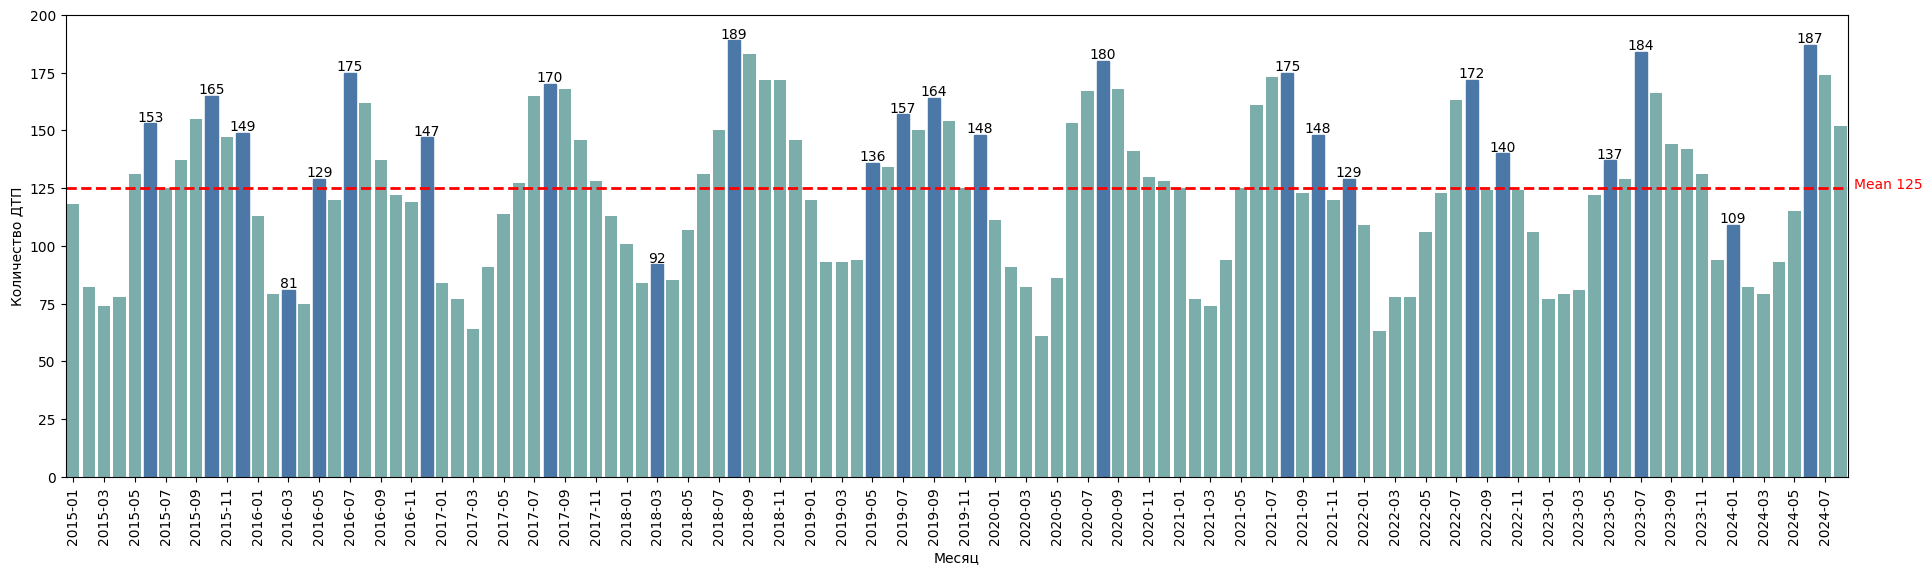

In [107]:
# Размер графика и сам график
plt.figure(figsize=(23, 6))
sns.barplot(x=df.index, y=df.values, color='#72B7B2')

# Cреднее значение
mean_value1 = df.mean()

plt.axhline(
    y=mean_value1,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value1:.0f}'
)

plt.text(
    len(df) -0.1,
    mean_value1,
    f'Mean {mean_value1:.0f}',
    color='red')

values = df.to_numpy()
peaks = np.zeros(len(values), dtype=bool)

peaks[1:-1] = (
    (values[1:-1] > values[:-2])
    &
    (values[1:-1] > values[2:])
)

# Перекрашиваю пики
for i, bar in enumerate(plt.gca().patches):
    if peaks[i]:
        bar.set_color('#4C78A8')

# Подписи пиков
for i, v in enumerate(values):
    if peaks[i]:
        plt.text(
            i,
            v + 1,
            str(v),
            ha='center',
            color='black'
        )

plt.xlabel('Месяц')
plt.ylabel('Количество ДТП')
plt.ylim(0, 200)
plt.xticks(plt.xticks()[0][::2])  # Каждая вторая подпись
plt.xticks(rotation=90)
plt.show()

# График за весь период исследования с обозначением пиков и среднего количества ДТП

### 4.2 График по дням недели за весь период

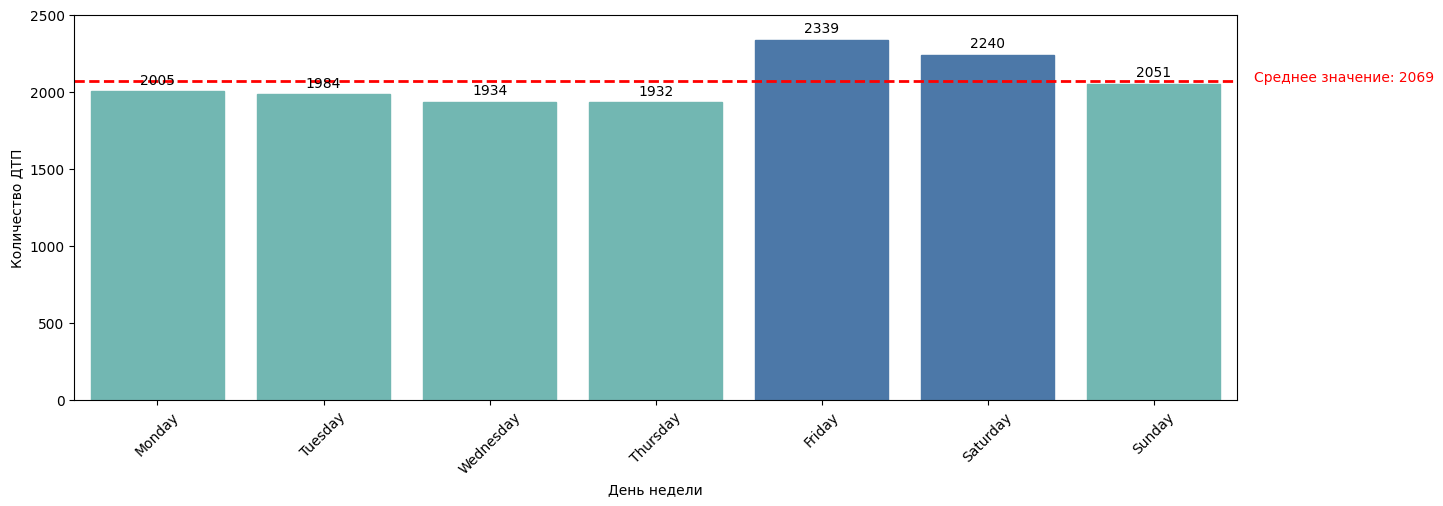

In [106]:
plt.figure(figsize=(15,5))
sns.barplot(x=df_week.index, y=df_week.values, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

mean_value_week = df_week.mean()

# Раскраска столбцов
for bar in plt.gca().patches:
    if bar.get_height() >= mean_value_week:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# Подписи значений над столбцами
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3)

# Вывожу среднюю линию на графике
plt.axhline(
    y=mean_value_week,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value_week:.0f}'
)

plt.text(
    len(df_week) - 0.4,
    mean_value_week,
    f'Среднее значение: {mean_value_week:.0f}',
    color='red'
)


plt.xlabel('День недели')
plt.ylabel('Количество ДТП')
plt.ylim(0, 2500)
plt.xticks(rotation=45)
plt.show()

### 4.3 График количества ДТП по месяцам за 2015–2023 годы

In [87]:
ko['month1'] = ko['datetime'].dt.month_name()
ko['year'] = ko['datetime'].dt.year

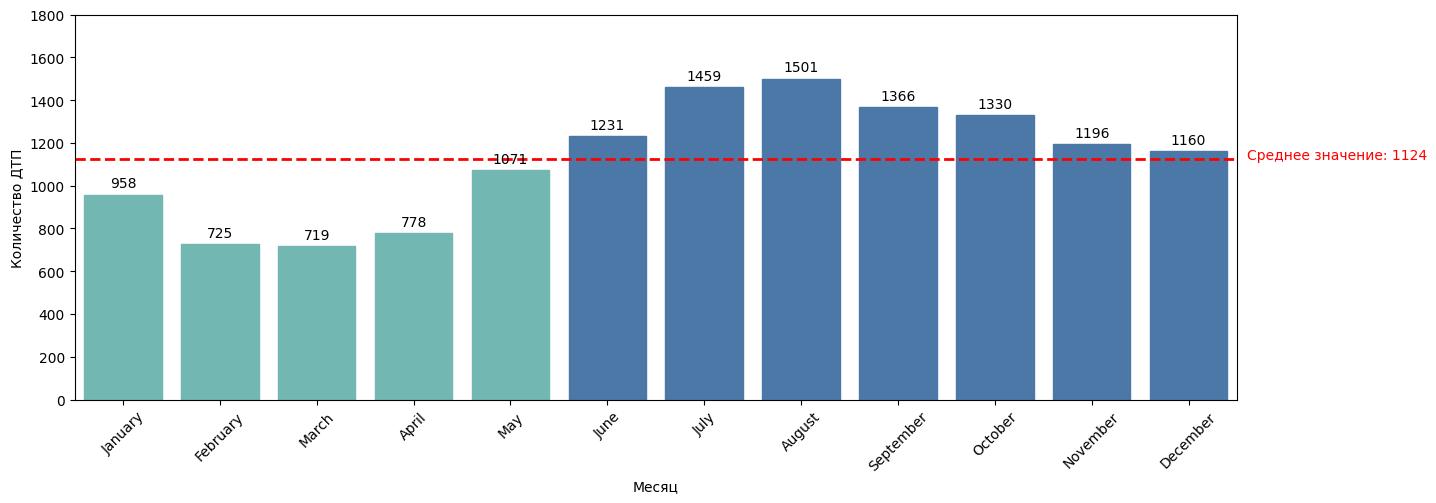

In [108]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

# Месяц с мах кол-вом ДТП
ko_m = ko[ko['year'] != 2024].groupby('month1')['id'].size().reindex(month_order)

# Основной график
plt.figure(figsize=(15,5))
sns.barplot(
    x=ko_m.index,
    y=ko_m.values,
    color='#72B7B2'
)

mean_value2 = ko_m.mean()

# Раскраска столбцов
for bar in plt.gca().patches:
    if bar.get_height() >= mean_value2:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# Подписи значений над столбцами
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3)

plt.axhline(
    y=mean_value2,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value2:.0f}')

plt.text(
    len(ko_m) -0.4,
    mean_value2,
    f'Среднее значение: {mean_value2:.0f}',
    color='red')

plt.xlabel('Месяц')
plt.ylabel('Количество ДТП')
plt.ylim(0, 1800)
plt.xticks(rotation=45)
plt.show()

### 4.4 График количества ДТП по годам за 2015–2023 годы

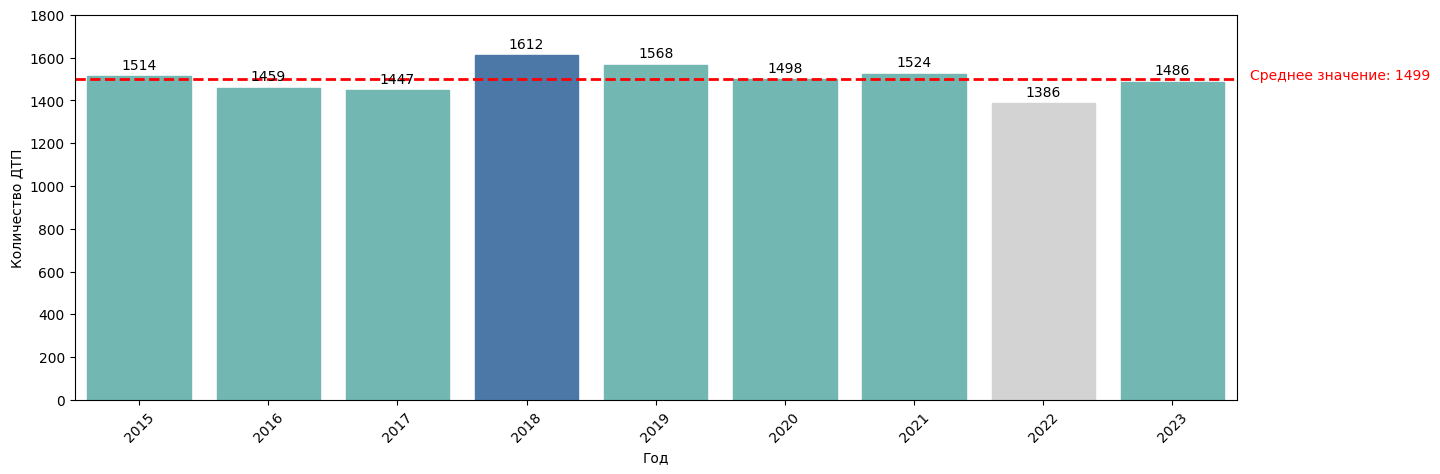

In [98]:
# Год с мах кол-вом ДТП
ko_y = ko[ko['year'] != 2024].groupby('year')['id'].size()

mean_value_year = ko_y.mean()
max_value_year = ko_y.max()
min_value_year = ko_y.min()

# Основной график
plt.figure(figsize=(15,5))
sns.barplot(
    x=ko_y.index,
    y=ko_y.values,
    color='#72B7B2')

# раскраска столбцов
for bar in plt.gca().patches:
    if bar.get_height() == min_value_year:
        bar.set_color('lightgrey')
    elif bar.get_height() == max_value_year:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3)

plt.axhline(
    y=mean_value_year,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value_year:.0f}')

plt.text(
    len(ko_y) -0.4,
    mean_value_year,
    f'Среднее значение: {mean_value_year:.0f}',
    color='red')

plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.ylim(0, 1800)
plt.xticks(rotation=45)
plt.show()

## 5. Сравнение количества ДТП между группами водителей с разным стажем в Кировской области

In [111]:
# Водители с известным стажем
drivers = participants_ko[
    (participants_ko['role'] == 'Водитель')
    & participants_ko['years_of_driving_experience'].notna()
]

# Количество уникальных ДТП с участием водителей каждого стажа
a = (
    drivers
    .groupby('years_of_driving_experience')['id']
    .nunique()
)

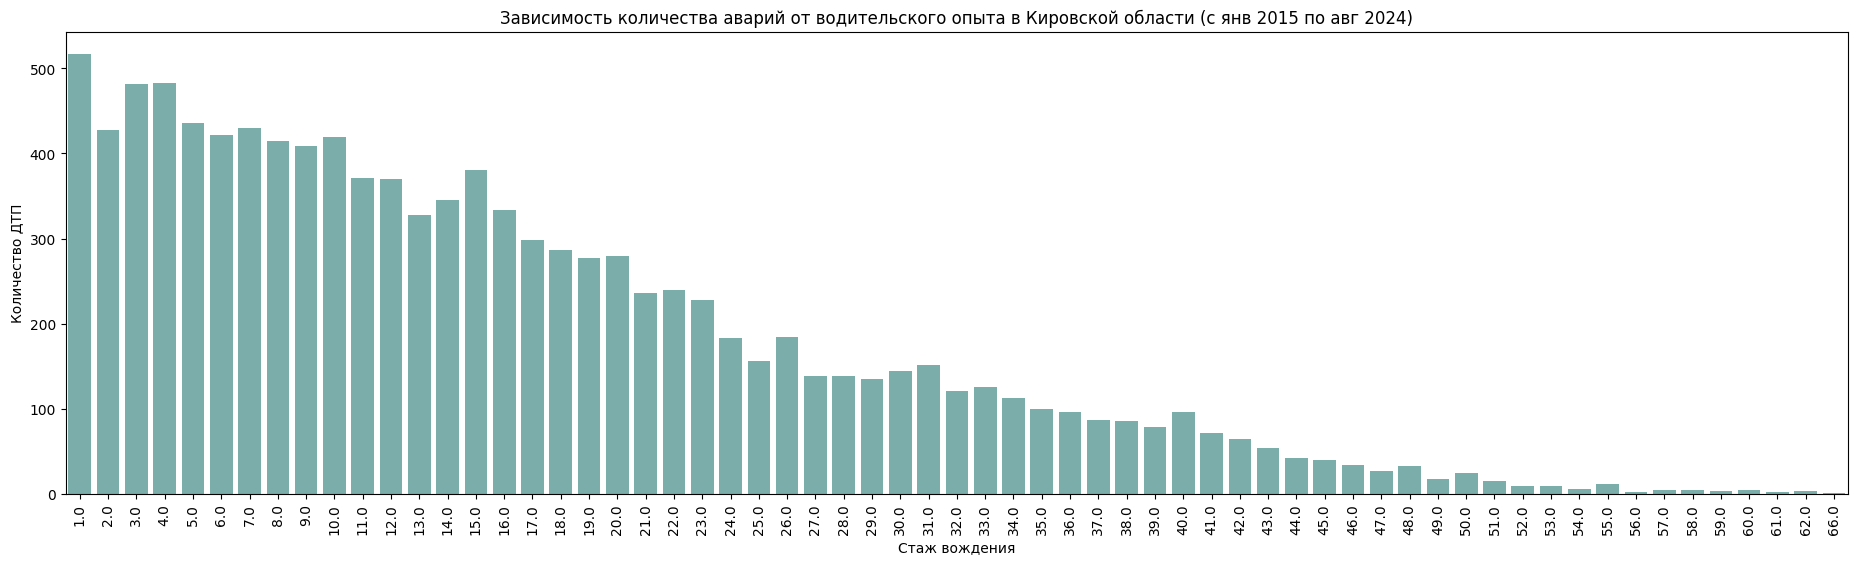

In [114]:
plt.figure(figsize=(23,6))
sns.barplot(
    x=a.index,
    y=a.values,
    color='#72B7B2')

plt.xlabel('Стаж вождения')
plt.ylabel('Количество ДТП')
plt.title('Количество ДТП с участием водителей разного стажа в Кировской области (с янв 2015 по авг 2024)')
plt.xticks(rotation=90)
plt.show()